In [1]:

import sys
import os
import warnings
import numpy as np
import pandas as pd
import json
from pathlib import Path

warnings.filterwarnings('ignore')

# Make sure parent path is available
sys.path.append('/Users/juanrios/Documents/master_thesis')

from causallearn.utils.Dataset import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from causal_discovery.causal_discovery import LiNGAMWithFCI, PCWithFCI
from predictive_models.predictive_models import LGBMRegressor
from explainability_models import (
    ShapleyFromScratch, AsymmetricShapley,
    ShapleyFlowWrapper, CausalShapley
)

# ── Pipeline parameters (matching experimental_pipeline.py) ──────────────────
RANDOM_STATE        = 42
TEST_SIZE           = 0.2
BACKGROUND_RATIO    = 0.3
TEST_INSTANCES_RATIO = 0.5
N_SHAPLEY_SAMPLES   = 100
M_INNER_SAMPLES_CAUSAL = 10
LINGAM_ALPHA        = 0.05
PC_ALPHA            = 0.05
INDEP_TEST          = "fisherz"

# Target protein to predict (designated Y in the pipeline)
TARGET_PROTEIN      = "akt"

print("Imports OK")


Imports OK


## Step 1 — Load & Preprocess Sachs Cell Signalling Dataset

`causallearn.utils.Dataset.load_dataset('sachs')` returns the Sachs et al. (2005) *Science* dataset of 7466 simultaneous protein/phospholipid measurements in human T-cells.

| Property | Value |
|---|---|
| Observations | 7 466 |
| Variables | 11 continuous protein/lipid concentrations |
| Target Y | `akt` (Akt kinase — downstream node in two signalling pathways) |
| True DAG | 17 directed edges (Sachs 2005 consensus model) |

**Preprocessing pipeline applied to X (before train/test split):**
1. `np.log1p` — stabilises right-skewed log-normal distributions, making marginals approximately Gaussian (required for Fisher-z in PC)
2. `StandardScaler` (fit on train only) — brings all proteins to μ=0, σ=1 so LiNGAM's |coef|<0.10 pruning threshold is scale-consistent


`akt` is removed from X and used as the regression target Y (kept in original scale).

In [2]:

data_raw, labels = load_dataset('sachs')
df_raw = pd.DataFrame(data_raw, columns=labels)
print(f"Raw data loaded: {df_raw.shape}")
print(f"Proteins: {labels}")
df_raw.head(3)


Raw data loaded: (7466, 11)
Proteins: ['raf', 'mek', 'plc', 'pip2', 'pip3', 'erk', 'akt', 'pka', 'pkc', 'p38', 'jnk']


,raf,mek,plc,pip2,pip3,erk,akt,pka,pkc,p38,jnk
0,26.4,13.2,8.82,18.3,58.80,6.61,17.0,414.0,17.00,44.9,40.0
1,35.9,16.5,12.30,16.8,8.13,18.60,32.5,352.0,3.37,16.5,61.5
2,59.4,44.1,14.60,10.2,13.00,14.90,32.5,403.0,11.40,31.9,19.5


In [3]:

# akt is the designated regression target; all other proteins are features X
y = df_raw[TARGET_PROTEIN].astype(np.float64)
y = pd.Series(y.values, name='Y')

X_raw_conc = df_raw.drop(columns=[TARGET_PROTEIN]).astype(np.float64)
X_raw_conc.index = range(len(X_raw_conc))

# Step 1a: log1p-transform — stabilises right-skewed (log-normal) protein distributions.
# log1p is a fixed, deterministic transform — no data leakage, safe to apply before split.
# Protein relationships are multiplicative in raw space → additive in log space,
# which also helps LiNGAM's linear SEM assumption.
X = np.log1p(X_raw_conc)

print(f"X shape  : {X.shape}")
print(f"Features : {X.columns.tolist()}")
print(f"y (Akt)  : mean={y.mean():.2f}  std={y.std():.2f}  "
      f"min={y.min():.0f}  max={y.max():.0f}")
print(f"X log1p  : mean={X.values.mean():.3f}  std={X.values.std():.3f}")
X.head(3)


X shape  : (7466, 10)
Features : ['raf', 'mek', 'plc', 'pip2', 'pip3', 'erk', 'pka', 'pkc', 'p38', 'jnk']
y (Akt)  : mean=81.17  std=137.77  min=1  max=3555
X log1p  : mean=3.555  std=1.554


,raf,mek,plc,pip2,pip3,erk,pka,pkc,p38,jnk
0,3.310543,2.653242,2.284421,2.960105,4.091006,2.029463,6.028279,2.890372,3.826465,3.713572
1,3.608212,2.862201,2.587764,2.879198,2.211566,2.975530,5.866468,1.474763,2.862201,4.135167
2,4.100989,3.808882,2.747271,2.415914,2.639057,2.766319,6.001415,2.517696,3.493473,3.020425


In [4]:
## Step 2 — Train / Test Split (80 / 20)


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Step 1b: StandardScaler — fit on X_train only to avoid data leakage.
# Brings all proteins to μ=0, σ=1 so LiNGAM's |coef|<0.10 pruning threshold
# is scale-consistent across all proteins regardless of raw concentration range.
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"X_train after log+scale: mean={X_train.values.mean():.4f}  std={X_train.values.std():.4f}")


Train: (5972, 10)  |  Test: (1494, 10)
X_train after log+scale: mean=-0.0000  std=1.0000


## Step 3 — Train LGBM Model


In [6]:

clf = LGBMRegressor()
clf.fit(X_train, y_train, feature_selection=False)

y_pred = clf.predict(X_test)
print("Validation metrics:", clf.metrics)
print(f"Test R²  : {r2_score(y_test, y_pred):.4f}")


Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
Validation metrics: {'train_rmse': np.float64(18.03838366515867), 'train_mae': 10.976377544356797, 'train_r2': 0.9811326499727371, 'train_mse': 325.38328525146306, 'val_rmse': np.float64(29.101373652767467), 'val_mae': 15.191689242341972, 'val_r2': 0.9553302572711942, 'val_mse': 846.8899484779885}
Test R²  : 0.6786


## Step 4 — Causal Discovery (LiNGAM & PC on X-only training data)


In [7]:

lingam_disc = LiNGAMWithFCI(alpha=LINGAM_ALPHA, indep_test=INDEP_TEST)
pc_disc     = PCWithFCI(alpha=PC_ALPHA, indep_test=INDEP_TEST)

print("Running LiNGAM …")
results_lingam = lingam_disc.get_causal_relationships(X_train, model=clf)

print("Running PC …")
results_pc = pc_disc.get_causal_relationships(X_train, model=clf)

print("Done.")
print(f"LiNGAM adj shape: {np.array(results_lingam['adjacency_matrix']).shape}")
print(f"PC     adj shape: {np.array(results_pc['adjacency_matrix']).shape}")


Running LiNGAM …
Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 26 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2327.71it/s]


X1 --> X2
X7 --> X1
X2 --> X7
X3 --> X4
X3 --> X10
X10 --> X5
X8 --> X6
X9 --> X7
X9 --> X10
FCI detected 12 potential confounders pairs
Y edges added: 10 (model features ∪ sink nodes)
Running PC …
 Running PC algorithm for causal structure discovery...


Depth=5, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 3755.31it/s]


   Removed 2 edge(s) to break cycles:
      9 -> 1
      4 -> 2
PC discovered 19 edges (after cycle removal)
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2491.86it/s]

X1 --> X2


X7 --> X1
X2 --> X7
X3 --> X4
X3 --> X10
X10 --> X5
X8 --> X6
X9 --> X7
X9 --> X10
FCI detected 12 potential confounders pairs
Y edges added: 10 (model features ∪ sink nodes)
Done.
LiNGAM adj shape: (11, 11)
PC     adj shape: (11, 11)


## Step 5 — Build Full Adjacency Matrices (X + Y node)

The Sachs dataset has a well-known ground-truth DAG (Sachs et al. 2005, *Science*).  
We build `full_adj` (n_features+1 × n_features+1) by extending each discovered X-only graph with X→Y edges, using the same rule as the pipeline: **model features** + **sink nodes** (features with no outgoing X→X edges).  
`Y = akt` occupies the last row/column.


In [8]:

feature_names = X_train.columns.tolist()   # X feature names only
n_feat = len(feature_names)

def build_full_adj(results: dict, model) -> np.ndarray:
    """
    Extend discovered X-only adjacency (n×n) to (n+1×n+1) by adding X→Y edges.
    Mirrors the logic in run_causal_discovery() of experimental_pipeline.py.
    Y is placed at index n_feat (last column/row).
    """
    full_adj_disc = np.array(results['adjacency_matrix'])   # already (n+1)×(n+1) from get_causal_relationships
    # get_causal_relationships already appends Y; verify shape
    assert full_adj_disc.shape == (n_feat + 1, n_feat + 1), \
        f"Unexpected shape {full_adj_disc.shape}"
    return full_adj_disc

lingam_full_adj = build_full_adj(results_lingam, clf)
pc_full_adj     = build_full_adj(results_pc,     clf)

# X-only adjacency (for CausalShapley)
lingam_train_adj = lingam_full_adj[:-1, :-1]
pc_train_adj     = pc_full_adj[:-1, :-1]

print(f"LiNGAM: {int(lingam_train_adj.sum())} X→X edges, "
      f"{int(lingam_full_adj[:-1, -1].sum())} X→Y edges")
print(f"PC    : {int(pc_train_adj.sum())} X→X edges, "
      f"{int(pc_full_adj[:-1, -1].sum())} X→Y edges")


LiNGAM: 26 X→X edges, 10 X→Y edges
PC    : 19 X→X edges, 10 X→Y edges


## Step 6 — Prepare Background & Test Instances for Shapley

| Set | Pipeline rule | Target size |
|---|---|---|
| Background | 30 % of train rows | ~24 k × 0.3 |
| Test instances | 50 % of test rows, capped so ≤ 100 | 100 |


In [9]:

# Background: 30 % of train
n_background = int(len(X_train) * BACKGROUND_RATIO)
background_data = X_train.sample(n=n_background, random_state=RANDOM_STATE)

# Test instances: 50 % of test, capped at 100 to match pipeline intent
n_test_inst = min(int(len(X_test) * TEST_INSTANCES_RATIO), 100)
test_instances = X_test.sample(n=n_test_inst, random_state=RANDOM_STATE)

# ShapleyFlow needs Y column in the data frames
background_data_flow = background_data.copy()
background_data_flow['Y'] = y_train.loc[background_data.index]

test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_test.loc[test_instances.index]

print(f"Background rows : {len(background_data)}")
print(f"Test instances  : {len(test_instances)}")


Background rows : 1791
Test instances  : 100


## Step 7 — Compute Shapley Values (7 combinations)

| # | Method | Graph |
|---|---|---|
| 1 | ShapleyFromScratch | — |
| 2 | AsymmetricShapley | PC |
| 3 | CausalShapley | PC |
| 4 | ShapleyFlow | PC |
| 5 | AsymmetricShapley | LiNGAM |
| 6 | CausalShapley | LiNGAM |
| 7 | ShapleyFlow | LiNGAM |


In [10]:

# ── 1. ShapleyFromScratch (no causal graph) ──────────────────────────────────
print("[1/7] ShapleyFromScratch …")
scratch_exp = ShapleyFromScratch(
    clf, background_data,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE
)
shap_scratch = scratch_exp.explain(test_instances, method='monte_carlo')
imp_scratch  = scratch_exp.get_feature_importance()
print(f"  shape={shap_scratch.shape}")


[1/7] ShapleyFromScratch …
Computing Shapley values from scratch using monte_carlo method...
  shape=(100, 10)


In [11]:

# ── PC methods ────────────────────────────────────────────────────────────────
pc_confounders   = results_pc['confounders']
pc_feature_names = results_pc['feature_names']   # includes 'Y' at the end

# 2. PC + AsymmetricShapley
print("[2/7] PC + AsymmetricShapley …")
asym_pc_exp = AsymmetricShapley(
    clf, background_data,
    causal_graph=pc_full_adj,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_asym_pc = asym_pc_exp.explain(test_instances, method='monte_carlo')
imp_asym_pc  = asym_pc_exp.get_feature_importance()
print(f"  shape={shap_asym_pc.shape}")

# 3. PC + CausalShapley
print("[3/7] PC + CausalShapley …")
causal_pc_exp = CausalShapley(
    clf,
    background_data=background_data,
    discovered_adj=pc_train_adj,
    discovered_conf=pc_confounders,
    feature_names=[f for f in pc_feature_names if f != 'Y'],
    n_samples=N_SHAPLEY_SAMPLES,
    M_inner_samples=M_INNER_SAMPLES_CAUSAL,
    random_state=RANDOM_STATE,
)
shap_causal_pc = causal_pc_exp.explain(test_instances)
imp_causal_pc  = causal_pc_exp.get_feature_importance()
print(f"  shape={shap_causal_pc.shape}")

# 4. PC + ShapleyFlow
print("[4/7] PC + ShapleyFlow …")
flow_pc_exp = ShapleyFlowWrapper(
    model=clf,
    background_data=background_data_flow,
    causal_graph=pc_full_adj,
    y_index=len(pc_feature_names) - 1,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_flow_pc = flow_pc_exp.explain(test_instances_flow)
imp_flow_pc  = flow_pc_exp.get_feature_importance()
print(f"  shape={shap_flow_pc.shape}")


[2/7] PC + AsymmetricShapley …
Computing Asymmetric Shapley values (random topological ordering, monte_carlo mode)...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
  shape=(100, 10)
[3/7] PC + CausalShapley …
Computing Causal Shapley values (post-interventional sampling)...
  Instances: 100, Permutations: 100, Inner samples: 10
  Estimated predictions: 1,000,000
  Instance 1/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations: 60/100
     Permutations: 80/100
     Permutations: 100/100
  Instance 2/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations: 60/100
     Permutations: 80/100
     Permutations: 100/100
  Instance 3/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations: 60/100


In [12]:

# ── LiNGAM methods ────────────────────────────────────────────────────────────
lingam_confounders   = results_lingam['confounders']
lingam_feature_names = results_lingam['feature_names']   # includes 'Y' at the end

# 5. LiNGAM + AsymmetricShapley
print("[5/7] LiNGAM + AsymmetricShapley …")
asym_lingam_exp = AsymmetricShapley(
    clf, background_data,
    causal_graph=lingam_full_adj,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_asym_lingam = asym_lingam_exp.explain(test_instances, method='monte_carlo')
imp_asym_lingam  = asym_lingam_exp.get_feature_importance()
print(f"  shape={shap_asym_lingam.shape}")

# 6. LiNGAM + CausalShapley
print("[6/7] LiNGAM + CausalShapley …")
causal_lingam_exp = CausalShapley(
    clf,
    background_data=background_data,
    discovered_adj=lingam_train_adj,
    discovered_conf=lingam_confounders,
    feature_names=[f for f in lingam_feature_names if f != 'Y'],
    n_samples=N_SHAPLEY_SAMPLES,
    M_inner_samples=M_INNER_SAMPLES_CAUSAL,
    random_state=RANDOM_STATE,
)
shap_causal_lingam = causal_lingam_exp.explain(test_instances)
imp_causal_lingam  = causal_lingam_exp.get_feature_importance()
print(f"  shape={shap_causal_lingam.shape}")

# 7. LiNGAM + ShapleyFlow
print("[7/7] LiNGAM + ShapleyFlow …")
flow_lingam_exp = ShapleyFlowWrapper(
    model=clf,
    background_data=background_data_flow,
    causal_graph=lingam_full_adj,
    y_index=len(lingam_feature_names) - 1,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_flow_lingam = flow_lingam_exp.explain(test_instances_flow)
imp_flow_lingam  = flow_lingam_exp.get_feature_importance()
print(f"  shape={shap_flow_lingam.shape}")

print("\nAll Shapley computations done.")


[5/7] LiNGAM + AsymmetricShapley …
Computing Asymmetric Shapley values (random topological ordering, monte_carlo mode)...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
  shape=(100, 10)
[6/7] LiNGAM + CausalShapley …
Computing Causal Shapley values (post-interventional sampling)...
  Instances: 100, Permutations: 100, Inner samples: 10
  Estimated predictions: 1,000,000
  Instance 1/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations: 60/100
     Permutations: 80/100
     Permutations: 100/100
  Instance 2/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations: 60/100
     Permutations: 80/100
     Permutations: 100/100
  Instance 3/100...
     Permutations: 20/100
     Permutations: 40/100
     Permutations:

## Step 8 — Results: Feature Importance Comparison


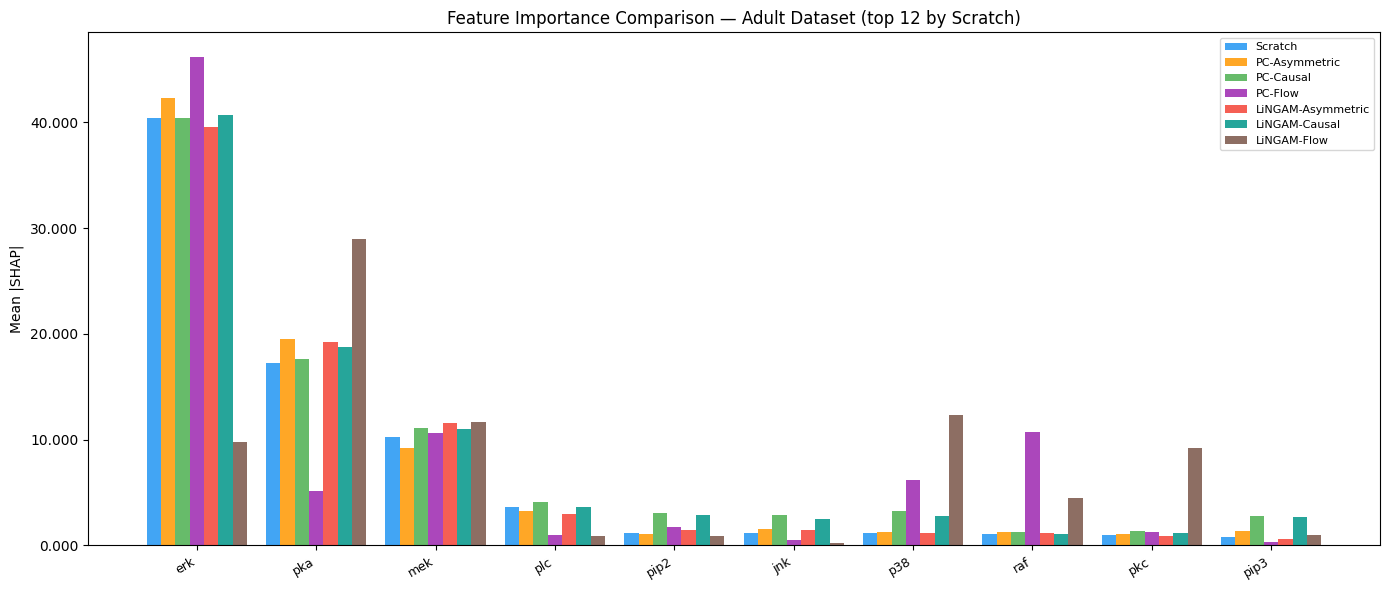

In [13]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Collect mean |SHAP| per method
all_importance = {
    'Scratch':         np.abs(shap_scratch).mean(axis=0),
    'PC-Asymmetric':   np.abs(shap_asym_pc).mean(axis=0),
    'PC-Causal':       np.abs(shap_causal_pc).mean(axis=0),
    'PC-Flow':         np.abs(shap_flow_pc).mean(axis=0),
    'LiNGAM-Asymmetric': np.abs(shap_asym_lingam).mean(axis=0),
    'LiNGAM-Causal':     np.abs(shap_causal_lingam).mean(axis=0),
    'LiNGAM-Flow':       np.abs(shap_flow_lingam).mean(axis=0),
}

# Build DataFrame sorted by Scratch importance (top 12 features)
imp_df = pd.DataFrame(all_importance, index=feature_names)
top_features = imp_df['Scratch'].nlargest(12).index.tolist()
imp_top = imp_df.loc[top_features]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_features))
width = 0.12
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0',
          '#F44336', '#009688', '#795548']

for i, (method, color) in enumerate(zip(all_importance.keys(), colors)):
    ax.bar(x + i * width, imp_top[method], width, label=method, color=color, alpha=0.85)

ax.set_xticks(x + width * 3)
ax.set_xticklabels(top_features, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Feature Importance Comparison — Adult Dataset (top 12 by Scratch)')
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()


In [14]:

# Rank correlation between Scratch and each causal method (Spearman)
from scipy.stats import spearmanr

scratch_ranks = imp_df['Scratch'].values
print("Spearman rank correlation vs Scratch:")
for method in list(all_importance.keys())[1:]:
    rho, pval = spearmanr(scratch_ranks, imp_df[method].values)
    print(f"  {method:<22s}  ρ={rho:.3f}  p={pval:.3e}")


Spearman rank correlation vs Scratch:
  PC-Asymmetric           ρ=0.782  p=7.547e-03
  PC-Causal               ρ=0.915  p=2.045e-04
  PC-Flow                 ρ=0.491  p=1.497e-01
  LiNGAM-Asymmetric       ρ=0.988  p=9.307e-08
  LiNGAM-Causal           ρ=0.891  p=5.421e-04
  LiNGAM-Flow             ρ=0.309  p=3.848e-01



## DAG Visualisation — True vs PC vs LiNGAM Causal Graphs

The **True DAG** X→X block is the 17-edge consensus model from Sachs et al. (2005), *Science* 308:523-529:

| Pathway | Directed edges |
|---|---|
| Lipid second-messenger | `plc → pip3`, `plc → pip2`, `pip3 → pip2`, `pip2 → pkc` |
| PKC cascade | `pkc → raf`, `pkc → mek`, `pkc → jnk`, `pkc → p38` |
| PKA cascade | `pka → raf`, `pka → mek`, `pka → erk`, `pka → jnk`, `pka → p38` |
| MAPK cascade | `raf → mek`, `mek → erk` |

**X→Y edge convention (pipeline-consistent):**  
X→Y edges in `true_full_adj` follow the same two rules as `run_causal_discovery()` in `experimental_pipeline.py`:
1. Every feature in `clf.selected_features` (LGBM model world)
2. Every **sink node** in the true X→X graph (no outgoing X→X edges) — ensures Y is reachable from all causal paths

This means edge recovery metrics compare the discovered graphs against the same "model world" definition of Y-parents used throughout the pipeline.


In [23]:

# ── Build true_full_adj from Sachs et al. 2005 consensus DAG ─────────────────
# Feature order: X.columns (10 proteins, akt excluded) + 'Y' at the end
# pc_feature_names = X feature names + ['Y'], matching the adjacency convention
all_names = pc_feature_names   # 10 protein names + 'Y'
_idx = {name: i for i, name in enumerate(all_names)}
n_total = len(all_names)
n_x = n_total - 1

true_full_adj = np.zeros((n_total, n_total), dtype=int)

# ── Lipid second-messenger pathway ───────────────────────────────────────────
true_full_adj[_idx['plc'],  _idx['pip3']] = 1   # plc  → pip3
true_full_adj[_idx['plc'],  _idx['pip2']] = 1   # plc  → pip2
true_full_adj[_idx['pip3'], _idx['pip2']] = 1   # pip3 → pip2
true_full_adj[_idx['pip2'], _idx['pkc']]  = 1   # pip2 → pkc

# ── PKC cascade ──────────────────────────────────────────────────────────────
true_full_adj[_idx['pkc'],  _idx['raf']]  = 1   # pkc  → raf
true_full_adj[_idx['pkc'],  _idx['mek']]  = 1   # pkc  → mek
true_full_adj[_idx['pkc'],  _idx['jnk']]  = 1   # pkc  → jnk
true_full_adj[_idx['pkc'],  _idx['p38']]  = 1   # pkc  → p38

# ── PKA cascade ──────────────────────────────────────────────────────────────
true_full_adj[_idx['pka'],  _idx['raf']]  = 1   # pka  → raf
true_full_adj[_idx['pka'],  _idx['mek']]  = 1   # pka  → mek
true_full_adj[_idx['pka'],  _idx['erk']]  = 1   # pka  → erk
true_full_adj[_idx['pka'],  _idx['jnk']]  = 1   # pka  → jnk  (inhibitory)
true_full_adj[_idx['pka'],  _idx['p38']]  = 1   # pka  → p38  (inhibitory)

# ── MAPK cascade ─────────────────────────────────────────────────────────────
true_full_adj[_idx['raf'],  _idx['mek']]  = 1   # raf  → mek
true_full_adj[_idx['mek'],  _idx['erk']]  = 1   # mek  → erk

# ── X→Y edges: mirror the experimental pipeline rule ─────────────────────────
# Rule 1: every feature that the LGBM regression model uses
# Rule 2: every sink node in the X→X true graph (no outgoing X→X edges)
# This matches run_causal_discovery() in experimental_pipeline.py so that
# accuracy metrics are computed on the same "model world" convention.
true_x_adj = true_full_adj[:n_x, :n_x]
y_parents: set = set()

# Rule 1 — model.selected_features
if hasattr(clf, 'selected_features') and clf.selected_features is not None:
    feat_index = {name: i for i, name in enumerate(feature_names)}
    for feat in clf.selected_features:
        if feat in feat_index:
            y_parents.add(feat_index[feat])

# Rule 2 — sink nodes (no outgoing X→X edges)
for i in range(n_x):
    if true_x_adj[i, :].sum() == 0:
        y_parents.add(i)

# Fallback: all features (should not trigger for Sachs)
if len(y_parents) == 0:
    y_parents = set(range(n_x))

for i in sorted(y_parents):
    true_full_adj[i, n_x] = 1

print("Sachs true full adjacency built (pipeline convention).")
print(f"  X→X edges : {int(true_full_adj[:n_x, :n_x].sum())}")
print(f"  X→Y edges : {int(true_full_adj[:n_x, -1].sum())}  "
      f"(features: {[feature_names[i] for i in sorted(y_parents)]})")
print(f"  Total edges: {int(true_full_adj.sum())}")


Sachs true full adjacency built (pipeline convention).
  X→X edges : 15
  X→Y edges : 10  (features: ['raf', 'mek', 'plc', 'pip2', 'pip3', 'erk', 'pka', 'pkc', 'p38', 'jnk'])
  Total edges: 25


### True-graph Shapley Values (for TGA / Sign-Alignment)

Compute Asymmetric, Causal, and ShapleyFlow using the **Sachs 2005 consensus DAG**
(`true_full_adj`) as the oracle causal graph.  These values are saved to disk so that
`real_data_analysis.ipynb` can compute **True-Graph Alignment (TGA)** and
**Sign Alignment** — measuring how well PC / LiNGAM-discovered attributions match
the ground-truth causal attributions.

The Sachs consensus DAG has no bidirected edges (it was inferred from interventional
data specifically to remove confounders), so `discovered_conf=[]` for CausalShapley.


In [ ]:

# ── True-graph Shapley values (oracle causal graph = Sachs 2005 consensus DAG) ──
#   true_full_adj  : (n+1)×(n+1) full adjacency  — AsymmetricShapley & ShapleyFlow
#   true_x_adj     : n×n  X-only block            — CausalShapley
#   discovered_conf: []  (no bidirected edges in Sachs consensus)

# 8. True + AsymmetricShapley
print("[8/10] True + AsymmetricShapley …")
asym_true_exp = AsymmetricShapley(
    clf, background_data,
    causal_graph=true_full_adj,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_asym_true = asym_true_exp.explain(test_instances, method='monte_carlo')
print(f"  shape={shap_asym_true.shape}")

# 9. True + CausalShapley
print("[9/10] True + CausalShapley …")
causal_true_exp = CausalShapley(
    clf,
    background_data=background_data,
    discovered_adj=true_x_adj,    # 10×10 X-only block (true_full_adj[:n_x, :n_x])
    discovered_conf=[],            # no bidirected edges in Sachs consensus DAG
    feature_names=feature_names,
    n_samples=N_SHAPLEY_SAMPLES,
    M_inner_samples=M_INNER_SAMPLES_CAUSAL,
    random_state=RANDOM_STATE,
)
shap_causal_true = causal_true_exp.explain(test_instances)
print(f"  shape={shap_causal_true.shape}")

# 10. True + ShapleyFlow
print("[10/10] True + ShapleyFlow …")
flow_true_exp = ShapleyFlowWrapper(
    model=clf,
    background_data=background_data_flow,
    causal_graph=true_full_adj,
    y_index=n_x,
    n_samples=N_SHAPLEY_SAMPLES,
    random_state=RANDOM_STATE,
)
shap_flow_true = flow_true_exp.explain(test_instances_flow)
print(f"  shape={shap_flow_true.shape}")

print("\nTrue-graph Shapley computations done.")


In [26]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Colour palette: deep-blue (far from Y) → orange-red (close to Y) ─────────
PROX_PALETTE = [
    "#2980b9", "#2471a3", "#1a6e9e", "#0e6fa5",
    "#1e88e5", "#4db6ac", "#66bb6a", "#d4e157",
    "#ffca28", "#ffa726", "#fb8c00", "#f4511e",
]


def build_dag_graph(adj: np.ndarray, names: list):
    """
    Build a DiGraph from an adjacency matrix and return topology metadata.

    Returns
    -------
    G         : nx.DiGraph  (nodes are name strings)
    topo_depth: dict  node → distance from nearest source (BFS from sources)
    max_levels: int   maximum topo_depth value (excl. Y)
    src_nodes : list  nodes with in-degree 0
    y_node    : node label for Y
    max_level : int   alias for max_levels
    """
    n = adj.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(names)
    for i in range(n):
        for j in range(n):
            if adj[i, j] != 0:
                G.add_edge(names[i], names[j])

    y_node = names[-1]  # Y is last by convention

    # BFS depth from source nodes (in-degree 0, excluding Y)
    src_nodes = [nd for nd in G.nodes() if G.in_degree(nd) == 0 and nd != y_node]
    topo_depth = {}
    queue = collections.deque()
    for s in src_nodes:
        topo_depth[s] = 0
        queue.append(s)
    while queue:
        node = queue.popleft()
        for child in G.successors(node):
            if child == y_node:
                continue
            new_d = topo_depth[node] + 1
            if child not in topo_depth or new_d > topo_depth[child]:
                topo_depth[child] = new_d
                queue.append(child)

    max_level = max((v for k, v in topo_depth.items() if k != y_node), default=0)
    return G, topo_depth, max_level, src_nodes, y_node, max_level


def make_dag_pos(topo_depth: dict, max_level: int, y_node: str = "Y",
                 G: nx.DiGraph = None):
    """
    Assign (x, y) positions for a layered DAG layout.
    Nodes are grouped by topo_depth; Y is placed at the right edge.
    """
    from collections import defaultdict
    layers = defaultdict(list)
    for nd, d in topo_depth.items():
        layers[d].append(nd)

    pos = {}
    total_layers = max_level + 1
    for depth, nodes_at_depth in layers.items():
        x = depth / max(total_layers, 1)
        for k, nd in enumerate(sorted(nodes_at_depth)):
            y_pos = (k + 1) / (len(nodes_at_depth) + 1)
            pos[nd] = (x, y_pos)

    # Y on the far right, vertically centred
    pos[y_node] = (1.05, 0.5)
    return pos


def draw_dag(ax, G: nx.DiGraph, pos: dict, topo_depth: dict,
             src_nodes: list, y_node: str, max_level: int, title: str):
    """Draw a single DAG panel onto *ax*."""
    ax.set_facecolor("#fafafa")

    # Node colours
    node_colors = []
    for nd in G.nodes():
        if nd == y_node:
            node_colors.append("#e74c3c")
        elif nd in src_nodes:
            node_colors.append(PROX_PALETTE[-1])
        else:
            d = topo_depth.get(nd, 0)
            idx = int(round(d / max(max_level, 1) * (len(PROX_PALETTE) - 1)))
            node_colors.append(PROX_PALETTE[max(0, len(PROX_PALETTE) - 1 - idx)])

    # Edge colours
    edge_colors = ["#c0392b" if v == y_node else "#bdc3c7" for u, v in G.edges()]
    edge_widths = [2.0 if v == y_node else 0.8 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=900, alpha=0.95)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors,
                           width=edge_widths, arrows=True,
                           arrowstyle="-|>", arrowsize=14,
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=18, min_target_margin=18)

    y_parents = [u for u, v in G.edges() if v == y_node]
    ax.set_title(
        f"{title}\n{G.number_of_edges()} edges  |  {len(y_parents)} direct Y-parents",
        fontsize=11, fontweight="bold", pad=10
    )
    ax.axis("off")


def draw_dag_highlight(ax, G: nx.DiGraph, pos: dict, topo_depth: dict,
                       src_nodes: list, y_node: str, max_level: int,
                       title: str, highlight_name: str):
    """
    Draw a DAG with one node highlighted; all other nodes and edges are muted.

    The highlighted node is drawn large with a vivid colour.
    Incoming edges are shown in blue (#2166ac), outgoing edges in orange-red (#d6604d).
    All other nodes and edges are muted grey so the focus node stands out.

    Parameters
    ----------
    highlight_name : name of the node to focus on, e.g. "pka" or "Y".
    """
    from matplotlib.lines import Line2D

    if highlight_name not in G.nodes():
        raise ValueError(f"'{highlight_name}' not found in graph nodes.")

    in_edges  = [(u, v) for u, v in G.edges() if v == highlight_name]
    out_edges = [(u, v) for u, v in G.edges() if u == highlight_name]
    bg_edges  = [(u, v) for u, v in G.edges() if u != highlight_name and v != highlight_name]

    n_in  = len(in_edges)
    n_out = len(out_edges)

    ax.set_facecolor("#f8f9fa")

    # Background edges (muted grey)
    if bg_edges:
        nx.draw_networkx_edges(G, pos, edgelist=bg_edges, ax=ax,
            edge_color="#dcdcdc", width=0.35, alpha=0.45,
            arrows=True, arrowstyle="->", arrowsize=5,
            connectionstyle="arc3,rad=0.08")

    # Incoming edges — blue
    if in_edges:
        nx.draw_networkx_edges(G, pos, edgelist=in_edges, ax=ax,
            edge_color="#2166ac", width=2.2, alpha=0.9,
            arrows=True, arrowstyle="->", arrowsize=14,
            connectionstyle="arc3,rad=0.08")

    # Outgoing edges — orange-red
    if out_edges:
        nx.draw_networkx_edges(G, pos, edgelist=out_edges, ax=ax,
            edge_color="#d6604d", width=2.2, alpha=0.9,
            arrows=True, arrowstyle="->", arrowsize=14,
            connectionstyle="arc3,rad=0.08")

    # Node colours / sizes
    nc, ns, ne, nlw = [], [], [], []
    for nd in G.nodes():
        if nd == highlight_name:
            nc.append("#e74c3c" if nd == y_node else "#f39c12")
            ns.append(1500)
            ne.append("#922b21" if nd == y_node else "#b7770d")
            nlw.append(2.5)
        elif nd == y_node:
            nc.append("#f1948a")
            ns.append(700)
            ne.append("#c0392b")
            nlw.append(1.0)
        else:
            nc.append("#eeeeee")
            ns.append(160)
            ne.append("#cccccc")
            nlw.append(0.4)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=nc, node_size=ns,
        alpha=0.95, linewidths=nlw, edgecolors=ne)

    # Labels: background small/grey; direct neighbours bolder; highlight large/bold
    bg_lbl  = {nd: nd for nd in G.nodes() if nd != highlight_name}
    nbr_lbl = {}
    for u, _ in in_edges:
        nbr_lbl[u] = u
    for _, v in out_edges:
        nbr_lbl[v] = v

    if bg_lbl:
        nx.draw_networkx_labels(G, pos, bg_lbl, ax=ax,
            font_size=5.0, font_color="#aaaaaa")
    if nbr_lbl:
        nx.draw_networkx_labels(G, pos, nbr_lbl, ax=ax,
            font_size=6.5, font_color="#2c3e50", font_weight="bold")
    nx.draw_networkx_labels(G, pos, {highlight_name: highlight_name}, ax=ax,
        font_size=9.0, font_color="#1a1a1a", font_weight="bold")

    # Stats annotation (bottom-left)
    depth_h  = topo_depth.get(highlight_name, "Y" if highlight_name == y_node else "?")
    src_note = "  (source — no parents)" if highlight_name in src_nodes else ""
    stats_str = (
        f"{highlight_name}  ·  depth {depth_h}{src_note}\n"
        f"in-edges : {n_in}   out-edges : {n_out}\n"
        f"graph    : {G.number_of_nodes()} nodes · {G.number_of_edges()} edges"
    )
    ax.text(0.01, 0.01, stats_str, transform=ax.transAxes,
        fontsize=8.0, va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88, ec="#cccccc"))

    # Legend (upper-right)
    legend_handles = [
        Line2D([0], [0], color="#2166ac", linewidth=2.0, label=f"Incoming ({n_in})"),
        Line2D([0], [0], color="#d6604d", linewidth=2.0, label=f"Outgoing ({n_out})"),
        Line2D([0], [0], color="#dcdcdc", linewidth=1.0, label="Other edges"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=8.0, framealpha=0.85)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")


def edge_recovery(ref_adj: np.ndarray, disc_adj: np.ndarray):
    """Precision / Recall / F1 of discovered edges vs reference."""
    ref_bin  = (ref_adj  != 0).astype(int)
    disc_bin = (disc_adj != 0).astype(int)
    tp = int((ref_bin & disc_bin).sum())
    fp = int(((disc_bin == 1) & (ref_bin == 0)).sum())
    fn = int(((ref_bin  == 1) & (disc_bin == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

print("Helper functions defined (draw_dag + draw_dag_highlight).")


Helper functions defined (draw_dag + draw_dag_highlight).


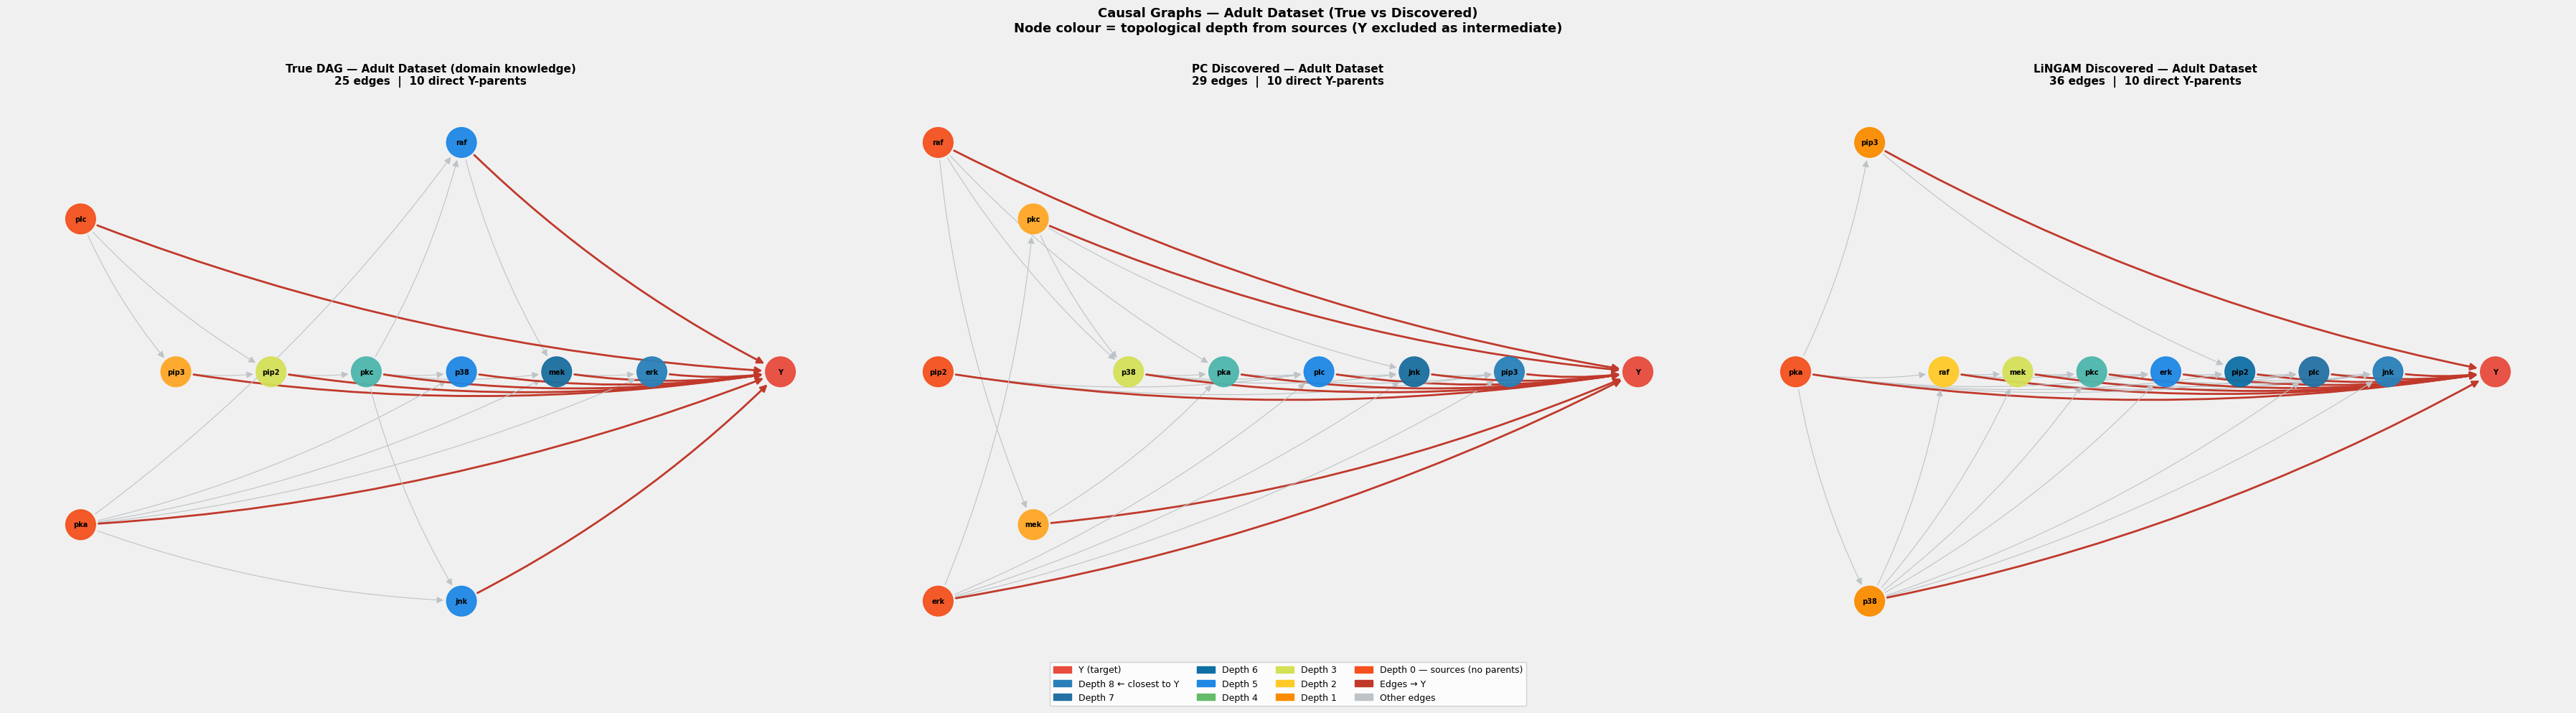

Saved dag_comparison_adult.png


In [25]:

# ── Build graphs from all three adjacency matrices ────────────────────────────
G_true,   td_true,   ml_true,   src_true,   y_true,   _ = build_dag_graph(true_full_adj, all_names)
G_pc,     td_pc,     ml_pc,     src_pc,     y_pc,     _ = build_dag_graph(pc_full_adj,   all_names)
G_lingam, td_lingam, ml_lingam, src_lingam, y_lingam, _ = build_dag_graph(lingam_full_adj, all_names)

pos_true   = make_dag_pos(td_true,   ml_true,   y_node=y_true,   G=G_true)
pos_pc     = make_dag_pos(td_pc,     ml_pc,     y_node=y_pc,     G=G_pc)
pos_lingam = make_dag_pos(td_lingam, ml_lingam, y_node=y_lingam, G=G_lingam)

# ── Draw 3-panel figure: True | PC | LiNGAM ──────────────────────────────────
fig_dags, axes = plt.subplots(1, 3, figsize=(36, 10))
fig_dags.patch.set_facecolor("#f0f0f0")

draw_dag(axes[0], G_true,   pos_true,   td_true,   src_true,   y_true,   ml_true,
         "True DAG — Adult Dataset (domain knowledge)")
draw_dag(axes[1], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         "PC Discovered — Adult Dataset")
draw_dag(axes[2], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         "LiNGAM Discovered — Adult Dataset")

# Shared legend
max_lv_all = max(ml_true, ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (target)")]
for prox in range(min(len(PROX_PALETTE), max_lv_all + 1)):
    idx = int(round(prox / max(max_lv_all, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_all - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == max_lv_all
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [
    mpatches.Patch(color="#c0392b", label="Edges → Y"),
    mpatches.Patch(color="#bdc3c7", label="Other edges"),
]
fig_dags.legend(handles=legend_entries, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))
fig_dags.suptitle(
    "Causal Graphs — Adult Dataset (True vs Discovered)\n"
    "Node colour = topological depth from sources (Y excluded as intermediate)",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.savefig("dag_comparison_adult.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved dag_comparison_adult.png")


In [18]:

# ── Comparison table: True | PC | LiNGAM ──────────────────────────────────────
rows = {}
for label, G, td, src, y_i, ml in [
    ("True",   G_true,   td_true,   src_true,   y_true,   ml_true),
    ("PC",     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ("LiNGAM", G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows[label] = {
        "nodes":      G.number_of_nodes(),
        "edges":      G.number_of_edges(),
        "direct_y":   sum(1 for u, v in G.edges() if v == y_i),
        "sources":    len(src),
        "max_depth":  ml,
        "depth_dist": collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f"{d[key]:>10}"

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print("─" * 64)
print(f"  {'Total nodes':<30}"             + "".join(_fmt(rows[m], "nodes")     for m in ["True", "PC", "LiNGAM"]))
print(f"  {'Total edges':<30}"             + "".join(_fmt(rows[m], "edges")     for m in ["True", "PC", "LiNGAM"]))
print(f"  {'Direct Y-parents':<30}"        + "".join(_fmt(rows[m], "direct_y")  for m in ["True", "PC", "LiNGAM"]))
print(f"  {'Source nodes (depth 0)':<30}"  + "".join(_fmt(rows[m], "sources")   for m in ["True", "PC", "LiNGAM"]))
print(f"  {'Max topo depth':<30}"          + "".join(_fmt(rows[m], "max_depth") for m in ["True", "PC", "LiNGAM"]))

max_d_all = max(rows[m]["max_depth"] for m in rows)
for d in range(max_d_all + 1):
    note = " (closest to Y)" if d == max_d_all else ""
    vals = "".join(f"{rows[m]['depth_dist'].get(d, 0):>10}" for m in ["True", "PC", "LiNGAM"])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery vs true_full_adj ────────────────────────────────────────────
pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_full_adj, pc_full_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_full_adj, lingam_full_adj)

print(f"\n{'Edge Recovery vs True DAG':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")



Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           11        11        11
  Total edges                           18        29        36
  Direct Y-parents                       3        10        10
  Source nodes (depth 0)                 2         3         1
  Max topo depth                         6         6         8
  Nodes at depth 0                       2         3         1
  Nodes at depth 1                       1         2         2
  Nodes at depth 2                       1         1         1
  Nodes at depth 3                       1         1         1
  Nodes at depth 4                       3         1         1
  Nodes at depth 5                       1         1         1
  Nodes at depth 6                       1         1         1
  Nodes at depth 7                       0         0         1
  Nodes at depth 8 (closest to Y)         0      


## DAG Highlight — Focus on a Single Protein

`draw_dag_highlight` mutes everything except the selected node:
- **Blue arrows** = incoming edges (parents)
- **Orange-red arrows** = outgoing edges (children)
- Change `FOCUS_PROTEIN` to any protein name or `"Y"` to inspect that node across all three graphs.


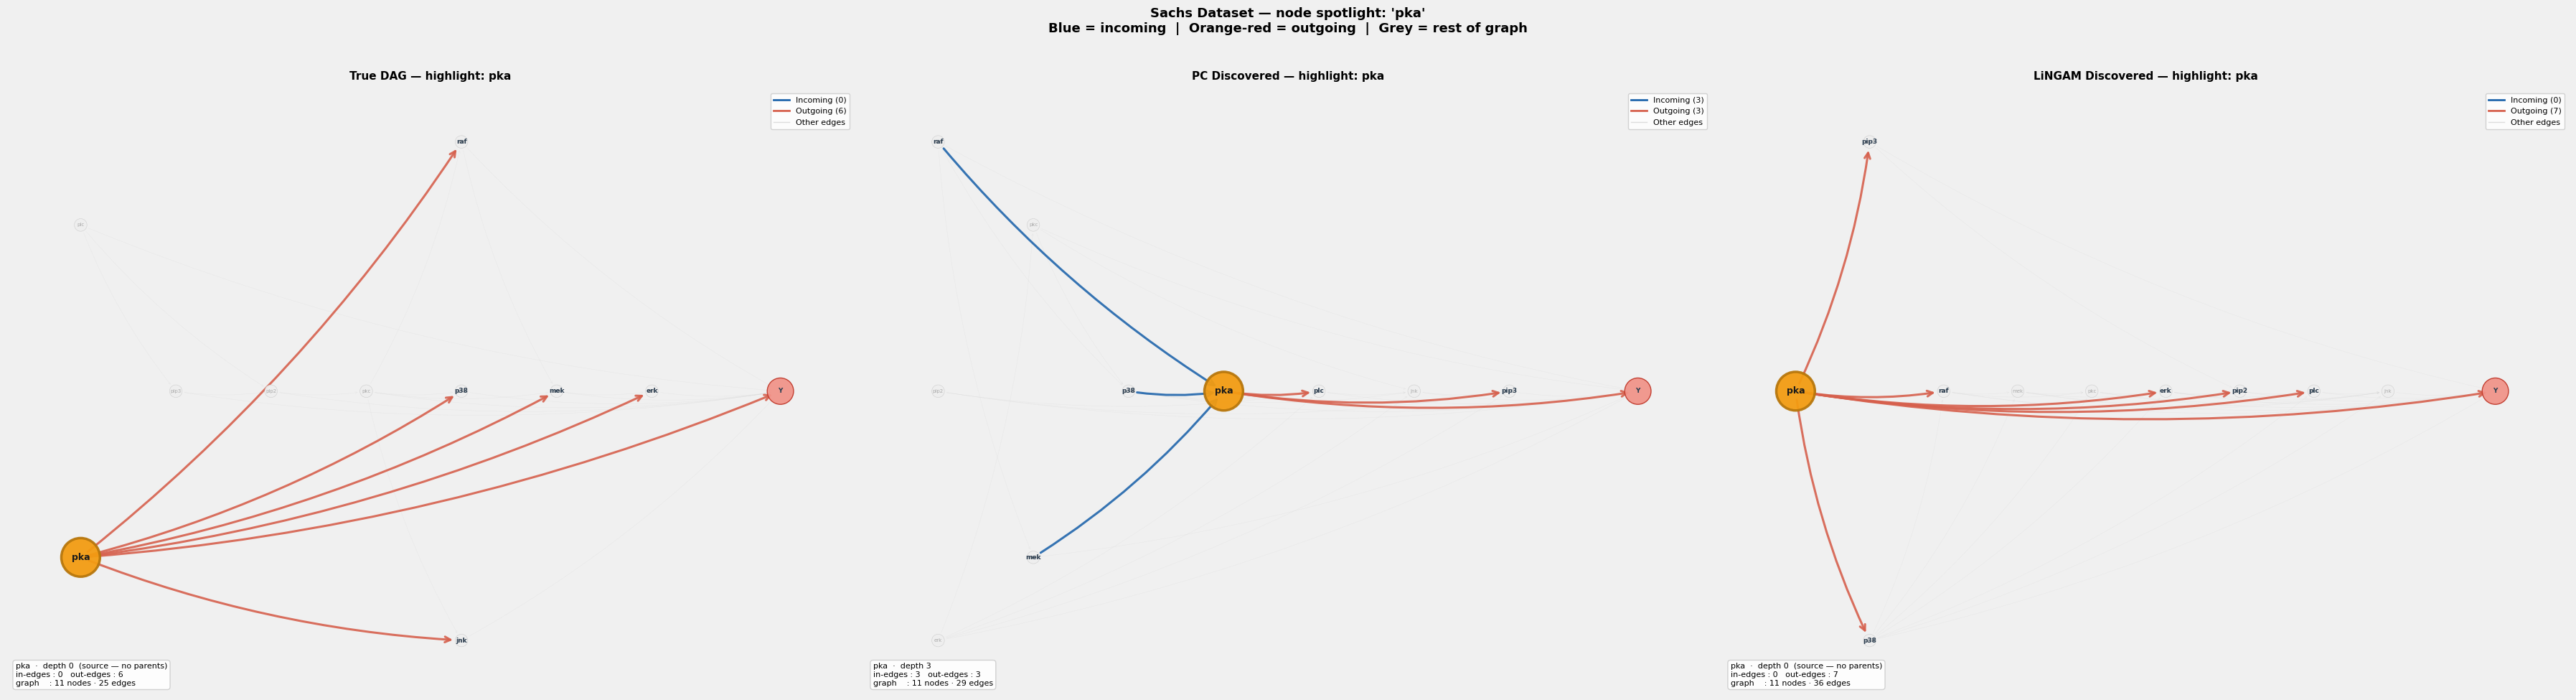

In [28]:

def plot_dag_highlight(focus_protein: str):
    """
    Draw a 3-panel highlight figure (True | PC | LiNGAM) focused on *focus_protein*.

    Parameters
    ----------
    focus_protein : str
        Name of the protein to spotlight, e.g. "pka", "erk", "Y".
        Must be one of the node names in all_names.
    """
    fig, axes = plt.subplots(1, 3, figsize=(36, 10))
    fig.patch.set_facecolor("#f0f0f0")

    draw_dag_highlight(axes[0], G_true,   pos_true,   td_true,   src_true,   y_true,   ml_true,
                       f"True DAG — highlight: {focus_protein}", focus_protein)
    draw_dag_highlight(axes[1], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
                       f"PC Discovered — highlight: {focus_protein}", focus_protein)
    draw_dag_highlight(axes[2], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
                       f"LiNGAM Discovered — highlight: {focus_protein}", focus_protein)

    fig.suptitle(
        f"Sachs Dataset — node spotlight: '{focus_protein}'\n"
        "Blue = incoming  |  Orange-red = outgoing  |  Grey = rest of graph",
        fontsize=13, fontweight="bold", y=0.99,
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
plot_dag_highlight("pka")


## Diagnostics — Why PC and LiNGAM Behave Differently on Sachs

Sachs is a continuous dataset, so both algorithms avoid the discrete-variable pitfalls seen in Adult.  
However, each algorithm has structural properties that interact with Sachs-specific characteristics:

### PC: performance depends on linearity and n
1. **Fisher-z assumes bivariate Gaussian marginals.** Protein concentrations are right-skewed (log-normal) — the conditional independence test is therefore misspecified, causing spurious or missed edges.
2. **Moderate n (n ≈ 5 900 train) keeps some false-positive pressure.** Min detectable |ρ| ≈ 0.026 at Fisher-z α = 0.05 — smaller genuine correlations may be detected as edges.
3. **CPDAG ambiguity.** PC returns a completed PDAG; undirected edges default to lower-index direction, generating spurious oriented edges.

### LiNGAM: theoretically best-suited to this data
1. **Non-Gaussianity is an asset.** DirectLiNGAM identifies the DAG under the assumption that noise terms are non-Gaussian — Sachs protein levels are strongly non-Gaussian (log-normal), which is exactly the regime LiNGAM is designed for.
2. **Linear SEM on log-normal data.** LiNGAM fits linear structural equations directly on the raw (non-log-transformed) data. If relationships are multiplicative in the original space, the linear approximation may still produce small coefficients, triggering the |coef| < 0.10 pruning threshold.
3. **Scale heterogeneity.** PKA measurements (mean ≈ 626, σ ≈ 644) are 20× larger than PIP3 (mean ≈ 27, σ ≈ 43). Raw LiNGAM coefficients are not scale-invariant — the 0.10 threshold pruning may disproportionately remove edges between high/low-scale pairs.


Feature distributional properties — Sachs training set

Protein        Skewness  Kurt (excess)     Normal p Verdict             
────────────────────────────────────────────────────────────────────────
  raf              0.54           0.88     2.29e-77  ✗ non-Gaussian (log-normal)
  mek              0.57           0.40     8.07e-69  ✗ non-Gaussian (log-normal)
  plc              1.03           1.90    3.32e-218  ✗ non-Gaussian (log-normal)
  pip2            -0.17          -0.44     6.04e-25  ✗ non-Gaussian (log-normal)
  pip3            -0.04           0.43     6.31e-08  ✗ non-Gaussian (log-normal)
  erk             -0.12          -0.26     1.42e-08  ✗ non-Gaussian (log-normal)
  pka             -1.49           2.22     0.00e+00  ✗ non-Gaussian (log-normal)
  pkc              0.50           0.87     2.38e-69  ✗ non-Gaussian (log-normal)
  p38              0.94           2.56    4.68e-220  ✗ non-Gaussian (log-normal)
  jnk              0.52           0.23     5.49e-55  ✗ non-Gaussian (

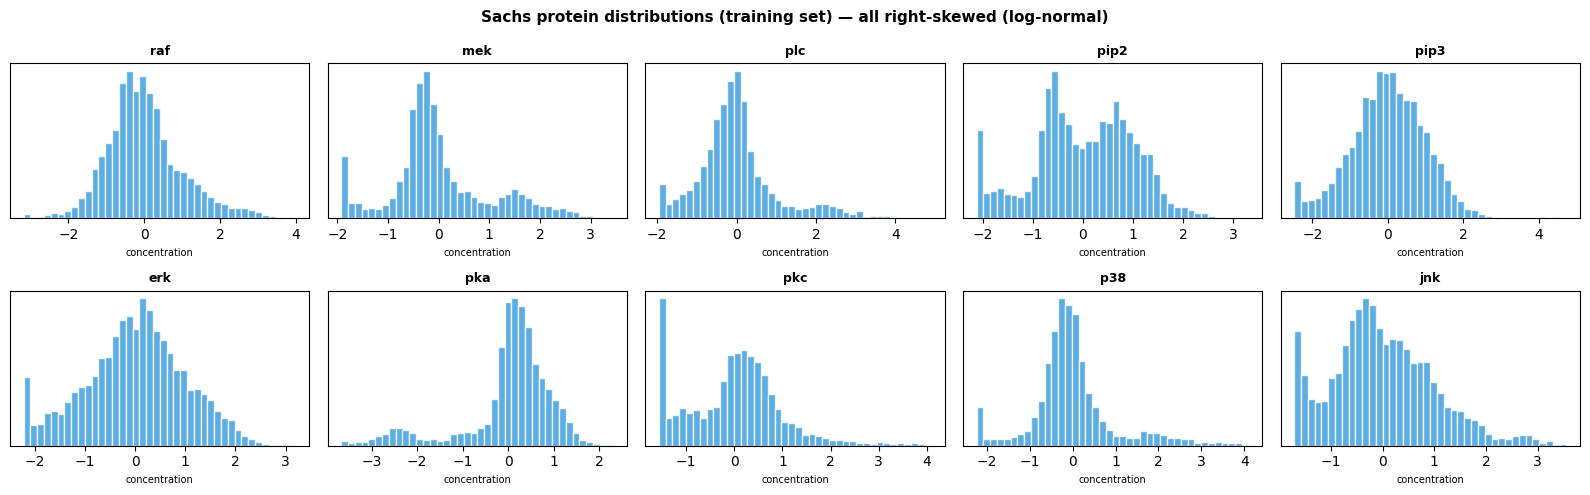

In [19]:

# ── Diagnostic 1: Feature non-Gaussianity (Fisher-z validity check) ──────────
# Fisher-z assumes multivariate Gaussianity.
# Sachs protein measurements are right-skewed (log-normal) — we quantify
# departure from normality using D'Agostino-Pearson (k²) test.
import matplotlib.pyplot as plt
from scipy.stats import normaltest, skew, kurtosis

print("Feature distributional properties — Sachs training set\n")
print(f"{'Protein':<12} {'Skewness':>10} {'Kurt (excess)':>14} {'Normal p':>12} {'Verdict':<20}")
print("─" * 72)

norm_results = {}
for feat in feature_names:
    vals = X_train[feat].dropna().values
    sk   = float(skew(vals))
    ku   = float(kurtosis(vals))   # excess kurtosis (0 = Gaussian)
    _, p = normaltest(vals)        # D'Agostino-Pearson
    norm_results[feat] = {'skew': sk, 'kurt': ku, 'p_normal': float(p)}
    verdict = "✗ non-Gaussian (log-normal)" if p < 0.05 else "✓ approx. Gaussian"
    print(f"  {feat:<10} {sk:>10.2f} {ku:>14.2f} {p:>12.2e}  {verdict}")

n_nongauss = sum(1 for v in norm_results.values() if v['p_normal'] < 0.05)
print(f"\n{n_nongauss}/{len(feature_names)} proteins fail normality (p<0.05)")
print("→ Fisher-z is misspecified for all of them (assumes Gaussian marginals)")
print("→ LiNGAM benefits: non-Gaussianity is its identification condition")

# Distribution plots for a few proteins
fig, axes = plt.subplots(2, 5, figsize=(16, 5))
for ax, feat in zip(axes.flatten(), feature_names):
    ax.hist(X_train[feat], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('concentration', fontsize=7)
    ax.set_yticks([])
plt.suptitle("Sachs protein distributions (training set) — all right-skewed (log-normal)",
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


Fitting raw DirectLiNGAM on X_train (no pruning) …
Non-zero coefficients before pruning: 38
After |coef| >= 0.10 pruning        : 26

True X→X edges vs LiNGAM coefficient magnitude (threshold=0.10):
  Surviving (|coef| ≥ 0.10): 7
  Pruned    (|coef| < 0.10): 8  ← false negatives from pruning


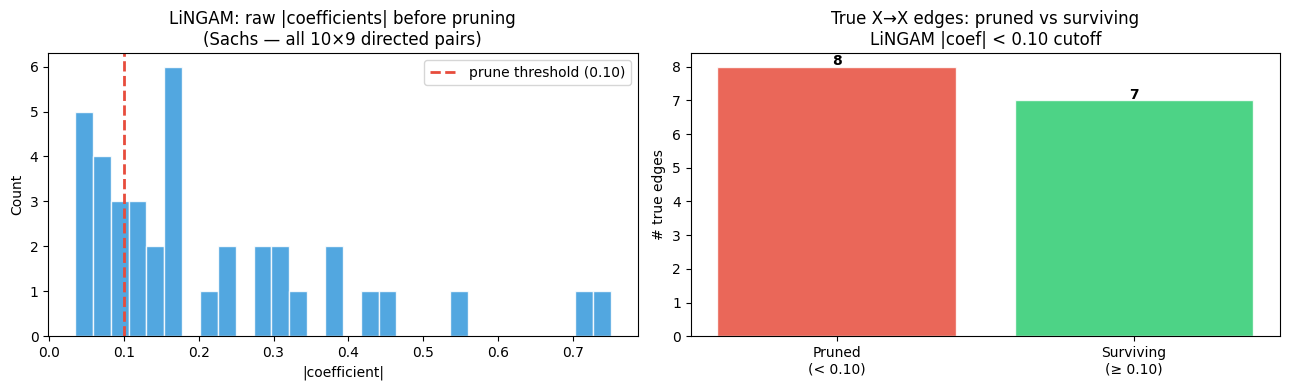


Conclusion: LiNGAM misses 8 of 15 true X→X edges due to
the |coef|<0.10 threshold on raw (unscaled) protein concentrations.


In [20]:

# ── Diagnostic 2: LiNGAM coefficient distribution & pruning impact ────────────
# Re-run raw DirectLiNGAM to get the unthresholded coefficient matrix.
# The pipeline wrapper prunes |coef| < 0.10 — we measure how many true edges
# it drops on the Sachs dataset.
from causallearn.search.FCMBased.lingam import DirectLiNGAM as RawLiNGAM

print("Fitting raw DirectLiNGAM on X_train (no pruning) …")
raw_lingam = RawLiNGAM()
raw_lingam.fit(X_train.values)

# causal-learn: adjacency_matrix_[i,j] = coef of X_j on X_i → transpose to i→j
raw_coef   = raw_lingam.adjacency_matrix_
raw_coef_T = raw_coef.T.copy()
np.fill_diagonal(raw_coef_T, 0)

flat_coefs = raw_coef_T[raw_coef_T != 0]
print(f"Non-zero coefficients before pruning: {len(flat_coefs)}")
print(f"After |coef| >= 0.10 pruning        : {int((np.abs(raw_coef_T) >= 0.10).sum())}")

# How many true X→X edges are killed by the threshold?
true_xx = true_full_adj[:-1, :-1]
killed = 0
surviving = 0
for i in range(n_feat):
    for j in range(n_feat):
        if true_xx[i, j] == 1:
            c = abs(raw_coef_T[i, j])
            if c < 0.10:
                killed += 1
            else:
                surviving += 1

print(f"\nTrue X→X edges vs LiNGAM coefficient magnitude (threshold=0.10):")
print(f"  Surviving (|coef| ≥ 0.10): {surviving}")
print(f"  Pruned    (|coef| < 0.10): {killed}  ← false negatives from pruning")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.abs(flat_coefs), bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0.10, color='#e74c3c', lw=2, ls='--', label='prune threshold (0.10)')
axes[0].set_xlabel('|coefficient|')
axes[0].set_ylabel('Count')
axes[0].set_title('LiNGAM: raw |coefficients| before pruning\n(Sachs — all 10×9 directed pairs)')
axes[0].legend()

axes[1].bar(['Pruned\n(< 0.10)', 'Surviving\n(≥ 0.10)'], [killed, surviving],
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[1].set_title('True X→X edges: pruned vs surviving\nLiNGAM |coef| < 0.10 cutoff')
axes[1].set_ylabel('# true edges')
for bar, val in zip(axes[1].patches, [killed, surviving]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nConclusion: LiNGAM misses {killed} of {killed+surviving} true X→X edges due to")
print("the |coef|<0.10 threshold on raw (unscaled) protein concentrations.")


Feature value ranges (X_train):

Feature                   Min        Max     StdDev   # unique
──────────────────────────────────────────────────────────────
  raf                    -3.2        4.0       1.00        670
  mek                    -1.9        3.5       1.00        835
  plc                    -2.0        4.9       1.00        722
  pip2                   -2.1        3.3       1.00        815
  pip3                   -2.5        4.7       1.00        570
  erk                    -2.2        3.2       1.00        575
  pka                    -3.7        2.3       1.00        769
  pkc                    -1.6        4.1       1.00        669
  p38                    -2.2        4.1       1.00        798
  jnk                    -1.7        3.6       1.00        781

Fitting raw DirectLiNGAM on *standardised* X_train …
True edges pruned  (|coef|<0.10, standardised): 8
True edges surviving (|coef|≥0.10, standardised): 7


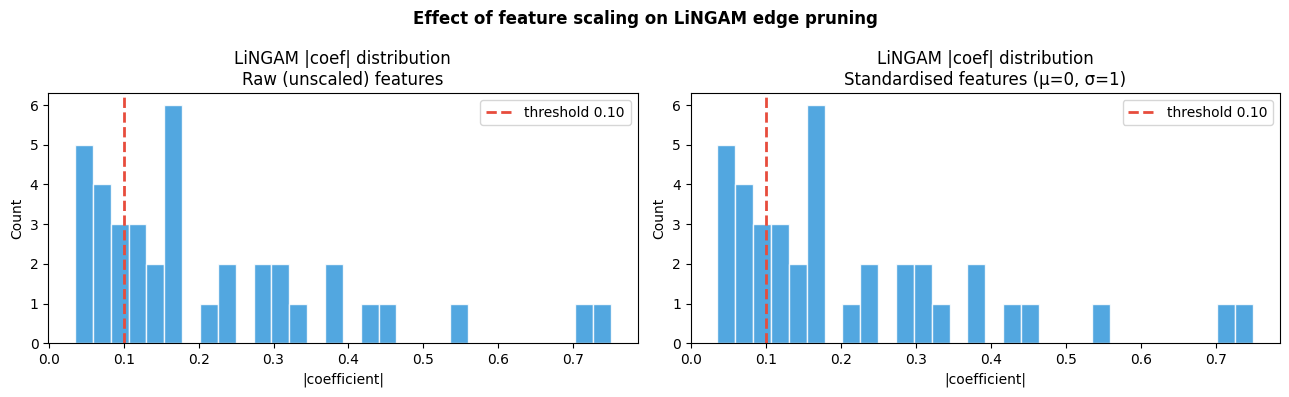


With standardised features: 8 pruned / 7 surviving (vs 8/7 unscaled)
If scaling recovers more true edges → scale heterogeneity is a key driver of LiNGAM's false negatives.


In [21]:

# ── Diagnostic 4: Scale heterogeneity & LiNGAM coefficient instability ────────
# LiNGAM solves a linear SEM. If features have very different scales,
# raw (unscaled) coefficients are not comparable to the 0.10 threshold.
print("Feature value ranges (X_train):\n")
print(f"{'Feature':<18} {'Min':>10} {'Max':>10} {'StdDev':>10} {'# unique':>10}")
print("─" * 62)
for feat in feature_names:
    col = X_train[feat]
    print(f"  {feat:<16} {col.min():>10.1f} {col.max():>10.1f} "
          f"{col.std():>10.2f} {col.nunique():>10}")

# Standardised version: what does LiNGAM give with z-scored features?
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
print("\nFitting raw DirectLiNGAM on *standardised* X_train …")
raw_lingam_scaled = RawLiNGAM()
raw_lingam_scaled.fit(X_train_scaled.values)
raw_coef_s = raw_lingam_scaled.adjacency_matrix_.T.copy()   # fix: adjacency_matrix_ (singular)
np.fill_diagonal(raw_coef_s, 0)

killed_s, surviving_s = 0, 0
for i in range(n_feat):
    for j in range(n_feat):
        if true_xx[i, j] == 1:
            c = abs(raw_coef_s[i, j])
            if c < 0.10:
                killed_s += 1
            else:
                surviving_s += 1

print(f"True edges pruned  (|coef|<0.10, standardised): {killed_s}")
print(f"True edges surviving (|coef|≥0.10, standardised): {surviving_s}")

# Side-by-side coefficient distributions
flat_scaled = raw_coef_s[raw_coef_s != 0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, coefs, title in [
    (axes[0], np.abs(raw_coef_T[raw_coef_T != 0]), "Raw (unscaled) features"),
    (axes[1], np.abs(flat_scaled),                  "Standardised features (μ=0, σ=1)"),
]:
    ax.hist(coefs, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    ax.axvline(0.10, color='#e74c3c', lw=2, ls='--', label='threshold 0.10')
    ax.set_xlabel('|coefficient|')
    ax.set_ylabel('Count')
    ax.set_title(f'LiNGAM |coef| distribution\n{title}')
    ax.legend()
plt.suptitle("Effect of feature scaling on LiNGAM edge pruning", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nWith standardised features: {killed_s} pruned / {surviving_s} surviving (vs {killed}/{surviving} unscaled)")
print("If scaling recovers more true edges → scale heterogeneity is a key driver of LiNGAM's false negatives.")


PC edge decomposition (X→X edges only):
  Correctly directed  :    3  (true edge, correct direction)
  Direction reversed  :    5  (true edge exists but PC reversed it)
  Spurious            :   11  (not in true graph at all)
  Missed (FN)         :   12  (true edge PC didn't find)
  Total PC X→X edges  :   19
  Total True X→X edges:   15

  → 11 spurious edges = PC over-estimates (n too large, Fisher-z too sensitive)
  → 5 reversed edges = PC skeleton is OK but orientation is wrong


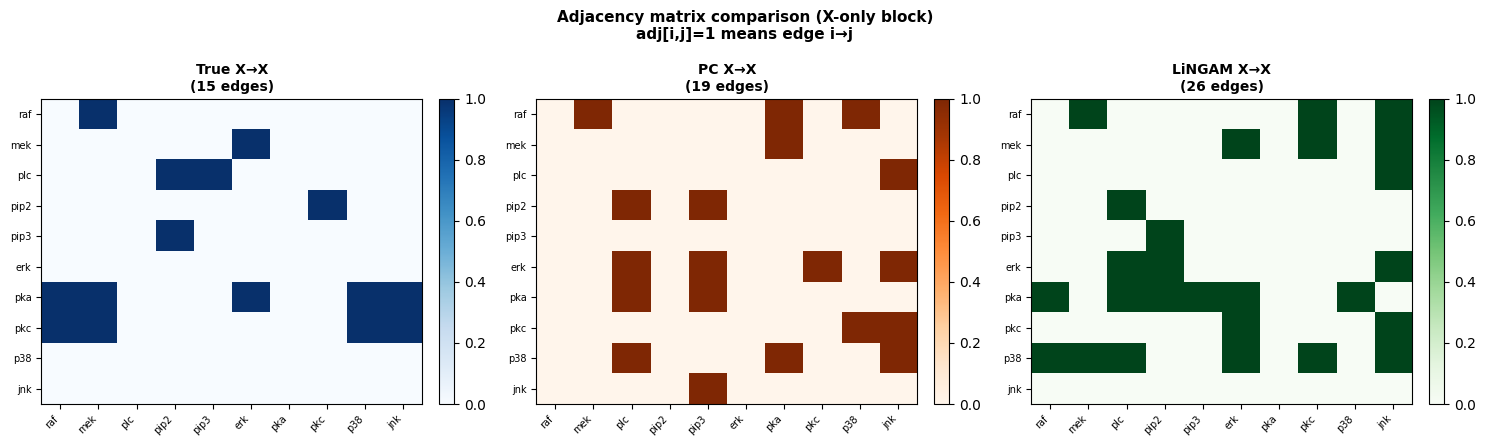

In [22]:

# ── Diagnostic 5: PC — skeleton vs oriented edges ────────────────────────────
# PC first builds an undirected skeleton (all correlated pairs), then orients
# edges using v-structures. Undirected edges get a default orientation.
# Here we measure: of PC's X→X edges, how many are in the true DAG?
# We split into "correctly oriented", "reversed", and "spurious".
pc_xx = pc_full_adj[:-1, :-1]

correct_dir   = int(((pc_xx == 1) & (true_xx == 1)).sum())        # TP with correct direction
reversed_dir  = int(((pc_xx == 1) & (true_xx.T == 1)).sum())     # edge exists but reversed
spurious      = int(((pc_xx == 1) & (true_xx == 0) & (true_xx.T == 0)).sum())  # not in true at all
missed        = int(((true_xx == 1) & (pc_xx == 0)).sum())        # true edge PC missed

print("PC edge decomposition (X→X edges only):")
print(f"  Correctly directed  : {correct_dir:>4}  (true edge, correct direction)")
print(f"  Direction reversed  : {reversed_dir:>4}  (true edge exists but PC reversed it)")
print(f"  Spurious            : {spurious:>4}  (not in true graph at all)")
print(f"  Missed (FN)         : {missed:>4}  (true edge PC didn't find)")
print(f"  Total PC X→X edges  : {int(pc_xx.sum()):>4}")
print(f"  Total True X→X edges: {int(true_xx.sum()):>4}")

print(f"\n  → {spurious} spurious edges = PC over-estimates (n too large, Fisher-z too sensitive)")
print(f"  → {reversed_dir} reversed edges = PC skeleton is OK but orientation is wrong")

# Summary heatmap: True vs PC vs LiNGAM adjacency side by side (X-only block)
lingam_xx = lingam_full_adj[:-1, :-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mat, title, cmap in [
    (axes[0], true_xx,   "True X→X",   "Blues"),
    (axes[1], pc_xx,     "PC X→X",     "Oranges"),
    (axes[2], lingam_xx, "LiNGAM X→X", "Greens"),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_feat)); ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(n_feat)); ax.set_yticklabels(feature_names, fontsize=7)
    ax.set_title(f"{title}\n({int(mat.sum())} edges)", fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Adjacency matrix comparison (X-only block)\nadj[i,j]=1 means edge i→j",
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


## Save Results to Disk

Persist all SHAP values, adjacency matrices, preprocessed data, and causal discovery results
so that `real_data_analysis.ipynb` can load them without re-running the full pipeline.


In [ ]:

import json as _json
from pathlib import Path as _Path

DATASET   = "sachs"
MODEL     = "lgbm"
BASE_DIR  = _Path('/Users/juanrios/Documents/master_thesis')

# ── Output directories ────────────────────────────────────────────────────────
EXP_BASE    = BASE_DIR / "data" / "explainability" / DATASET / MODEL
CAUSAL_OUT  = BASE_DIR / "data" / "causal"
PROC_OUT    = BASE_DIR / "data" / "processed"

SCRATCH_DIR = EXP_BASE / "scratch"

SHAP_ARRAYS = {
    SCRATCH_DIR:                          shap_scratch,
    EXP_BASE / "pc"     / "asymmetric":   shap_asym_pc,
    EXP_BASE / "pc"     / "causal":       shap_causal_pc,
    EXP_BASE / "pc"     / "flow":         shap_flow_pc,
    EXP_BASE / "lingam" / "asymmetric":   shap_asym_lingam,
    EXP_BASE / "lingam" / "causal":       shap_causal_lingam,
    EXP_BASE / "lingam" / "flow":         shap_flow_lingam,
    EXP_BASE / "true"   / "asymmetric":   shap_asym_true,
    EXP_BASE / "true"   / "causal":       shap_causal_true,
    EXP_BASE / "true"   / "flow":         shap_flow_true,
}

# ── 1. Save SHAP values ───────────────────────────────────────────────────────
for out_dir, arr in SHAP_ARRAYS.items():
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "shapley_values.npy", arr)
    print(f"Saved {arr.shape} → {out_dir.relative_to(BASE_DIR)}/shapley_values.npy")

# ── 2. Save adjacency matrices ────────────────────────────────────────────────
np.save(CAUSAL_OUT / f"{DATASET}_true_full_adjacency.npy",  true_full_adj)
np.save(CAUSAL_OUT / f"{DATASET}_pc_train_adjacency.npy",   pc_train_adj)
np.save(CAUSAL_OUT / f"{DATASET}_lingam_train_adjacency.npy", lingam_train_adj)
print(f"\nSaved adjacency matrices to {CAUSAL_OUT.relative_to(BASE_DIR)}/")

# ── 3. Save causal discovery results (JSON) ───────────────────────────────────
for method_name, (full_adj, conf, feat_names) in [
    ("pc",     (pc_full_adj,     pc_confounders,     pc_feature_names)),
    ("lingam", (lingam_full_adj, lingam_confounders, lingam_feature_names)),
]:
    out = {
        "adjacency_matrix": full_adj.tolist(),
        "feature_names":    feat_names,
        "confounders":      conf,
    }
    path = CAUSAL_OUT / f"{DATASET}_{method_name}_results.json"
    with open(path, "w") as _f:
        _json.dump(out, _f, indent=2)
    print(f"Saved {method_name.upper()} results → {path.relative_to(BASE_DIR)}")

# ── 4. Save preprocessed train/test parquet ───────────────────────────────────
train_df = X_train.copy(); train_df["Y"] = y_train.values
test_df  = X_test.copy();  test_df["Y"]  = y_test.values
train_df.to_parquet(PROC_OUT / f"{DATASET}_train.parquet", index=False)
test_df.to_parquet( PROC_OUT / f"{DATASET}_test.parquet",  index=False)
print(f"\nSaved train ({train_df.shape}) + test ({test_df.shape}) parquet to data/processed/")

# ── 5. Save metadata (y_parent_indices, feature_names) ────────────────────────
meta = {
    "dataset":          DATASET,
    "target_protein":   TARGET_PROTEIN,
    "feature_names":    feature_names,
    "y_parent_indices": sorted(y_parents),
    "y_parent_names":   [feature_names[i] for i in sorted(y_parents)],
    "n_features":       len(feature_names),
}
meta_path = BASE_DIR / "data" / "synthetic" / f"{DATASET}_metadata.json"
meta_path.parent.mkdir(parents=True, exist_ok=True)
with open(meta_path, "w") as _f:
    _json.dump(meta, _f, indent=2)
print(f"Saved metadata → {meta_path.relative_to(BASE_DIR)}")
print(f"\nDone. Y-parents ({len(y_parents)}): {meta['y_parent_names']}")


Saved (100, 10) → data/explainability/sachs/lgbm/scratch/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/pc/asymmetric/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/pc/causal/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/pc/flow/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/lingam/asymmetric/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/lingam/causal/shapley_values.npy
Saved (100, 10) → data/explainability/sachs/lgbm/lingam/flow/shapley_values.npy

Saved adjacency matrices to data/causal/
Saved PC results → data/causal/sachs_pc_results.json
Saved LINGAM results → data/causal/sachs_lingam_results.json

Saved train ((5972, 11)) + test ((1494, 11)) parquet to data/processed/
Saved metadata → data/synthetic/sachs_metadata.json

Done. Y-parents (10): ['raf', 'mek', 'plc', 'pip2', 'pip3', 'erk', 'pka', 'pkc', 'p38', 'jnk']
